In [1]:
import numpy as np
from astropy.table import Table, vstack, join

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
# ----------------------------- constants -----------------------------
Z_FID = 0.05 # fiducial redshift the velocities are re-referenced to
FIBER_FRAC = 0.40 # fiber sits at FIBER_FRAC * R26  (data col V_0p4R26)
SB_DIMMING_COEF = 10.0 # 2.5 * 4 : cosmological (1+z)^4 surface-brightness dimming
COG_R0_ARCSEC = 10.0 # SGA-2020 fixed curve-of-growth scale radius r0 (arcsec)
ALPHA_RC = 2.5 # rotation-curve shape param (Ravi+2024), held fixed
R_TURN_OVER_R26 = 0.25 # <-- PROVISIONAL: population R_turn/R26 from the Ravi+2024


def rotation_curve_log_slope(fiber_frac=FIBER_FRAC,
                             r_turn_over_r26=R_TURN_OVER_R26, alpha=ALPHA_RC):
    """d ln V / d ln r at r = fiber_frac*R26 for V(r)=Vmax r/(Rturn^a+r^a)^(1/a).
    r/Rturn = fiber_frac / r_turn_over_r26 (R26 cancels) => single population value."""
    ratio = fiber_frac / r_turn_over_r26
    xa = ratio ** alpha
    return 1.0 - xa / (1.0 + xa)

def _cog_mu_minus_muR26(s, u26, alpha2, m0):
    """mu(s*R26) - mu(R26) for the SGA-2020 curve of growth
    m(r) = mtot + m0 ln[1 + alpha1 (r/r0)^(-alpha2)],
    with surface brightness mu(r) = m(r) + 2.5 log10(r) - 2.5 log10(-m'(r)) + const.
    r0 and alpha1 cancel in the difference (only u(r)/u(R26)=(r/R26)^-alpha2 is used)."""
    us = u26 * s ** (-alpha2)
    dm = m0 * (np.log1p(us) - np.log1p(u26))
    mprime_ratio = s ** (-alpha2 - 1.0) * (1.0 + u26) / (1.0 + us)
    return dm + 2.5 * np.log10(s) - 2.5 * np.log10(mprime_ratio)

def corrected_logV(logV, z, R26, cog_m0, cog_alpha1, cog_alpha2):
    """Re-reference log10 V(0.4 R26) to the isophote evaluated at z = Z_FID.

    Inputs are SGA columns (arrays):
    logV        -> 'logV'              (= log10 V_0p4R26)
    z           -> 'Z_DESI'
    R26         -> 'SMA_SB26'          (arcsec; r-band 26 mag/arcsec^2 SMA)
    cog_m0      -> 'R_COG_PARAMS_M0'
    cog_alpha1  -> 'R_COG_PARAMS_ALPHA1'
    cog_alpha2  -> 'R_COG_PARAMS_ALPHA2'
    Returns (logV_corr, factor, delta_mu, delta). logV_ERR is UNCHANGED: a
    deterministic multiplicative factor on V is an additive shift in log10 V, so
    sigma(log10 V) is invariant (== scaling sigma_V by the same factor).
    Rows with invalid COG params return factor=NaN -> leave those uncorrected.
    """
    logV = np.asarray(logV, float); z = np.asarray(z, float); R26 = np.asarray(R26, float)
    m0 = np.asarray(cog_m0, float); a1 = np.asarray(cog_alpha1, float); a2 = np.asarray(cog_alpha2, float)
    log_slope = rotation_curve_log_slope()
    
    # step 1: SB shift of the isophote vs the fiducial redshift.
    # (k_mu surface-brightness k-correction difference omitted -- photometry is
    #  K-corrected to z=0.05 upstream; documented approximation.)
    delta_mu = SB_DIMMING_COEF * np.log10((1.0 + z) / (1.0 + Z_FID))
    
    # step 2: delta_mu -> fractional radius shift by inverting the COG SB profile.
    # Solve mu(r') = mu(R26) + delta_mu for r' = s*R26 (Newton). z>Z_FID => delta_mu>0
    # => observed R26 at smaller radius => target radius moves OUTWARD (delta>0).
    u26 = a1 * (R26 / COG_R0_ARCSEC) ** (-a2)
    s = np.ones_like(logV)
    for _ in range(80):
        f = _cog_mu_minus_muR26(s, u26, a2, m0) - delta_mu
        eps = 1e-4
        fp = (_cog_mu_minus_muR26(s + eps, u26, a2, m0)
              - _cog_mu_minus_muR26(s - eps, u26, a2, m0)) / (2 * eps)
        s = np.clip(s - np.where(np.abs(fp) > 1e-12, f / fp, 0.0), 0.1, 10.0)
    delta = s - 1.0
    
    # step 3: fractional radius shift -> velocity via the rotation-curve log-slope.
    factor = 1.0 + delta * log_slope
    logV_corr = logV + np.log10(factor)
    return logV_corr, factor, delta_mu, delta

In [3]:
vrot_cat = Table.read('vrot_cats/SGA-2020_loa_Vrot_v3.fits')
vrot_cat[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.97457016,0,0.08361393354574793,2.585694723746872e-05,N,136.40320332954073,12.846761926303119
32,SGA-2020 32,PGC2

In [4]:
logV_corr, factor, delta_mu, delta = corrected_logV(
    np.log10(vrot_cat['V_0p4R26']),
    vrot_cat["Z_DESI"],
    vrot_cat["SMA_SB26"],
    vrot_cat["R_COG_PARAMS_M0"],
    vrot_cat["R_COG_PARAMS_ALPHA1"],
    vrot_cat["R_COG_PARAMS_ALPHA2"],
)

/tmp/ipykernel_2270744/152683711.py:24: RuntimeWarning: invalid value encountered in log1p
  dm = m0 * (np.log1p(us) - np.log1p(u26))


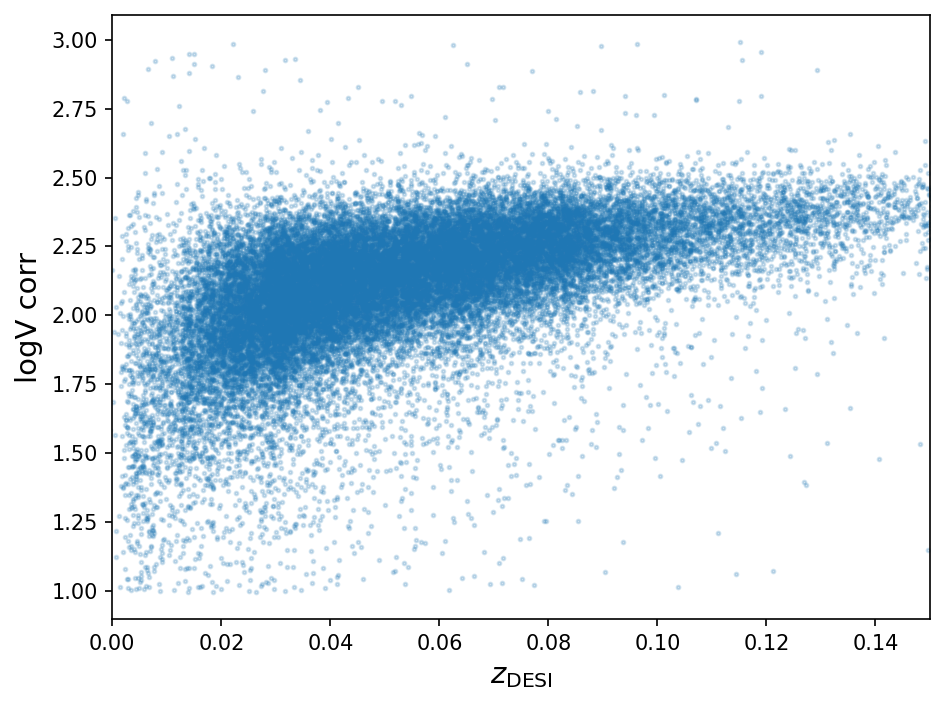

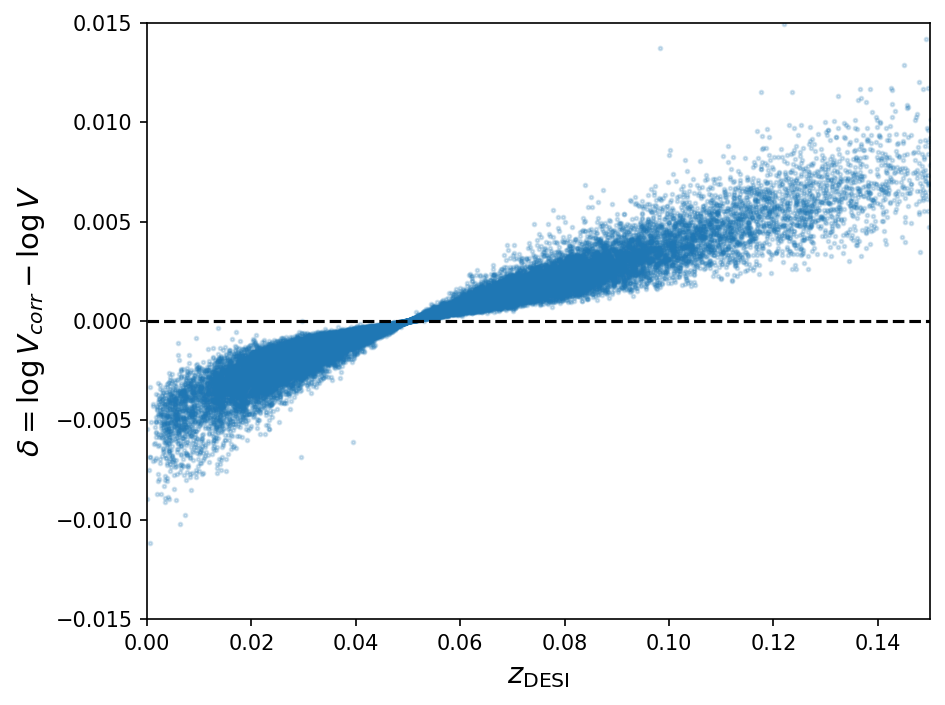

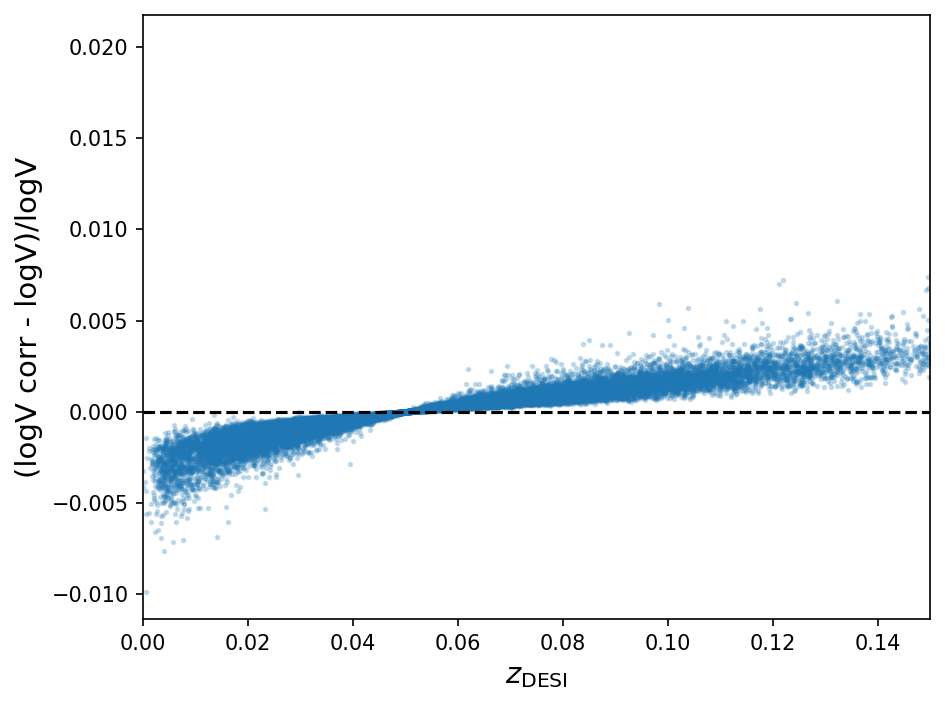

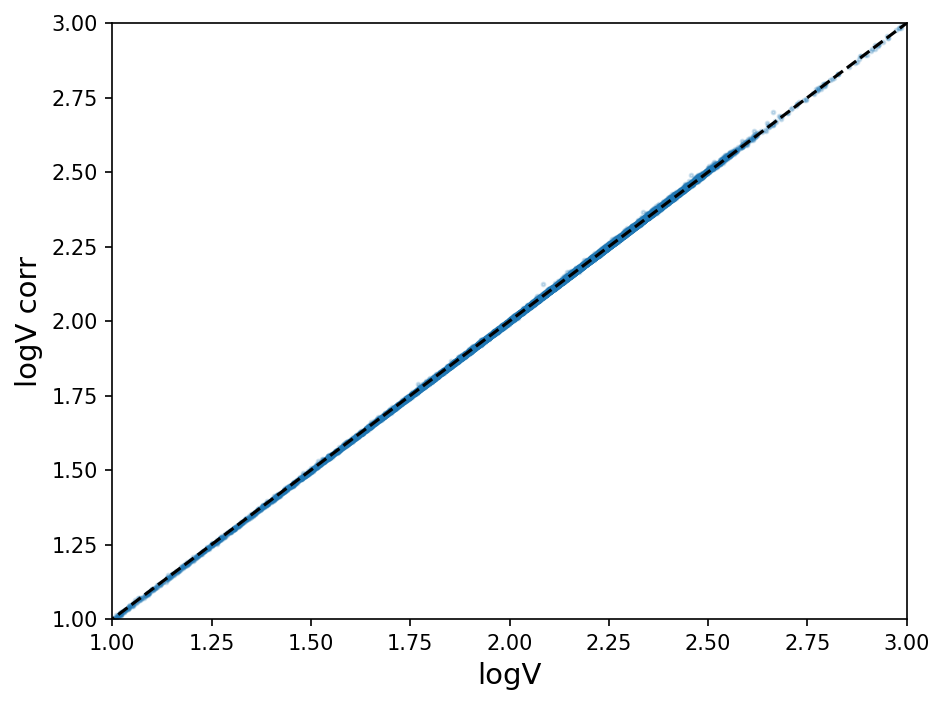

In [13]:
plt.figure(tight_layout=True, facecolor='none', dpi=150)
plt.scatter(vrot_cat['Z_DESI'], logV_corr, s=3, alpha=0.2)
plt.xlabel(r'$z_{\rm DESI}$', fontsize=14)
plt.ylabel('logV corr', fontsize=14)
plt.xlim(0,0.15)
plt.show();

plt.figure(tight_layout=True, facecolor='none', dpi=150)
plt.scatter(vrot_cat['Z_DESI'], (logV_corr - np.log10(vrot_cat['V_0p4R26'])), s=3, alpha=0.2)
plt.xlabel(r'$z_{\rm DESI}$', fontsize=14)
plt.ylabel(r'$\delta = \log V_{corr} - \log V$', fontsize=14)
plt.axhline(y=0, ls='dashed', color='k')
plt.xlim(0,0.15)
plt.ylim(-0.015,0.015)
plt.show();

plt.figure(tight_layout=True, facecolor='none', dpi=150)
plt.scatter(vrot_cat['Z_DESI'], (logV_corr - np.log10(vrot_cat['V_0p4R26']))/np.log10(vrot_cat['V_0p4R26']), s=3, alpha=0.2)
plt.xlabel(r'$z_{\rm DESI}$', fontsize=14)
plt.ylabel('(logV corr - logV)/logV', fontsize=14)
plt.axhline(y=0, ls='dashed', color='k')
plt.xlim(0,0.15)
# plt.ylim(-0.015,0.015)
plt.show();

plt.figure(tight_layout=True, facecolor='none', dpi=150)
plt.scatter(np.log10(vrot_cat['V_0p4R26']), logV_corr, s=3, alpha=0.2)
plt.plot([0,3],[0,3], ls='dashed', color='k')
plt.xlim(1,3)
plt.ylim(1,3)
plt.xlabel(r'logV', fontsize=14)
plt.ylabel('logV corr', fontsize=14)

plt.show()

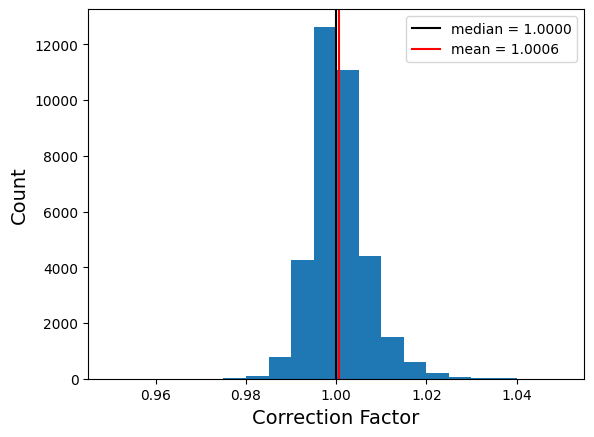

In [6]:
plt.figure()
plt.hist(factor, bins=np.arange(0.95,1.05,0.005))
plt.axvline(np.median(factor), label=f'median = {np.median(factor):.4f}', color='k')
plt.axvline(np.mean(factor), label=f'mean = {np.mean(factor):.4f}', color='r')


plt.xlabel('Correction Factor', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend()
plt.show()

In [7]:
vrot_cat['logV_SBcorr'] = logV_corr
vrot_cat['logV_correction_factor'] = factor

In [10]:
vrot_cat.write('vrot_cats/SGA-2020_loa_Vrot_v3_SBcorr_test.fits', overwrite=True)